# Gradient Boosting Regression

## What it does
Gradient Boosting builds an ensemble of shallow decision trees **sequentially**,
each tree correcting the residuals of the previous:

$$\hat{y} = \sum_{m=1}^{M} \eta \cdot h_m(x)$$

where $h_m$ is a weak learner (shallow tree) and $\eta$ is the learning rate.

## When to use it
- You expect **nonlinear** relationships or feature interactions
- Enough observations to support a tree ensemble
- Linear models have already been tried and underfit

## Key hyperparameters
| Parameter | Effect |
|---|---|
| `n_estimators` | Number of trees. More = lower bias, higher variance |
| `max_depth` | Depth per tree. Keep shallow (2–4) to avoid overfitting |
| `learning_rate` | Shrinks each tree's contribution. Smaller needs more trees |
| `subsample` | Fraction of training samples per tree. < 1 adds stochasticity |

## Notes
- **No standardization needed** — trees are invariant to monotone feature transformations.
- GBR is **slower** than linear models on large datasets. Use `subsample < 1` to speed up.
- Grid search over `(n_estimators, max_depth)` with `learning_rate` fixed.

## Configuration

Edit the values below to adapt this notebook to a new dataset.

In [1]:
CONFIG = {
    # --- Data ---
    'DATA_FILE':          '../../data/largeml.pq',
    'DATE_COL':           'yyyymm',
    'ID_COL':             'permno',
    'TARGET_COL':         'ret',
    # --- Time splits (year-based) ---
    'TRAIN_YEARS':        20,
    'VAL_YEARS':          12,
    # --- Preprocessing (no standardization for tree models) ---
    'MISSING_FILL_VALUE': 0,
    # --- GBR grid ---
    'N_ESTIMATORS_GRID':  [50, 100, 200],
    'MAX_DEPTH_GRID':     [2, 3, 5],
    'LEARNING_RATE':      0.1,
    'SUBSAMPLE':          0.8,
    # --- Portfolio ---
    'N_DECILES':          10,
    # --- Output ---
    'SAVE_RESULTS':       True,
    'OUTPUT_DIR':         'results',
}

print('Configuration loaded.')
for k, v in CONFIG.items():
    print(f'  {k}: {v}')

Configuration loaded.
  DATA_FILE: ../../data/largeml.pq
  DATE_COL: yyyymm
  ID_COL: permno
  TARGET_COL: ret
  TRAIN_YEARS: 20
  VAL_YEARS: 12
  MISSING_FILL_VALUE: 0
  N_ESTIMATORS_GRID: [50, 100, 200]
  MAX_DEPTH_GRID: [2, 3, 5]
  LEARNING_RATE: 0.1
  SUBSAMPLE: 0.8
  N_DECILES: 10
  SAVE_RESULTS: True
  OUTPUT_DIR: results


## Step 1 — Load Data & Define Time Splits

In [2]:
import sys, warnings, itertools
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('../../').resolve()))

from utils import (
    load_parquet, time_series_split, prepare_panel_data, drop_na_targets,
    compute_oos_r2, evaluate_splits,
    form_long_short_portfolio, portfolio_summary,
    build_run_summary, save_run_summary, save_portfolio_compositions,
)

df = load_parquet(CONFIG['DATA_FILE'])
df[CONFIG['DATE_COL']] = pd.to_numeric(df[CONFIG['DATE_COL']])
print(f'Dataset shape : {df.shape}')
print(f'Date range    : {df[CONFIG["DATE_COL"]].min()} — {df[CONFIG["DATE_COL"]].max()}')
df.head()

Dataset shape : (79146, 212)
Date range    : 192512 — 202211


,permno,yyyymm,AM,AOP,AbnormalAccruals,Accruals,AccrualsBM,Activism1,Activism2,AdExp,...,roaq,sfe,sinAlgo,skew1,std_turn,tang,zerotrade12M,zerotrade1M,zerotrade6M,ret
0,10078,198606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.393044e-08,NaN,-0.118056
1,10078,198607,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.737205e-08,NaN,-0.039370
2,10078,198609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.597698e-08,1.857281e-07,-0.008850
3,10078,198610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.763825e-08,2.111030e-07,0.348214
4,10078,198612,0.236302,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.718727,NaN,5.878542e-09,8.619326e-08,0.109827


In [3]:
train_mask, val_mask, test_mask, split_info = time_series_split(
    df, CONFIG['DATE_COL'], CONFIG['TRAIN_YEARS'], CONFIG['VAL_YEARS']
)
print(f"Training   : {split_info['train_start']} — {split_info['train_end']}  ({split_info['train_n_obs']:,} obs)")
print(f"Validation : {split_info['val_start']} — {split_info['val_end']}  ({split_info['val_n_obs']:,} obs)")
print(f"Test       : {split_info['test_start']} — {split_info['test_end']}  ({split_info['test_n_obs']:,} obs)")

Training   : 1925 — 1944  (889 obs)
Validation : 1945 — 1956  (709 obs)
Test       : 1957 — 2022  (77,548 obs)


## Step 2 — Prepare Features

> No standardization — decision trees are scale-invariant.

In [4]:
X, y, feature_cols = prepare_panel_data(
    df,
    target_col   = CONFIG['TARGET_COL'],
    exclude_cols = [CONFIG['DATE_COL'], CONFIG['ID_COL']],
    fill_value   = CONFIG['MISSING_FILL_VALUE'],
)

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

(X_train, y_train), (X_val, y_val), (X_test, y_test) = drop_na_targets(
    (X_train, y_train), (X_val, y_val), (X_test, y_test)
)

y_train_mean = float(y_train.mean())
print(f'Features {len(feature_cols)} | Train {X_train.shape[0]:,} | Val {X_val.shape[0]:,} | Test {X_test.shape[0]:,}')
print(f'Training mean return: {y_train_mean:.6f}')

Features 209 | Train 884 | Val 708 | Test 77,205
Training mean return: 0.007120


## Step 3 — Grid Search: n_estimators × max_depth

Best combination selected by **validation OOS R²**.

In [5]:
grid_results = []
combos = list(itertools.product(CONFIG['N_ESTIMATORS_GRID'], CONFIG['MAX_DEPTH_GRID']))
print(f'Evaluating {len(combos)} combinations...\n')

for n_est, max_d in combos:
    model = GradientBoostingRegressor(
        n_estimators=n_est, max_depth=max_d,
        learning_rate=CONFIG['LEARNING_RATE'],
        subsample=CONFIG['SUBSAMPLE'], random_state=42,
    )
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    oos_r2   = compute_oos_r2(y_val, val_pred, y_train_mean)
    grid_results.append({'n_estimators': n_est, 'max_depth': max_d, 'oos_r2_val': oos_r2, 'model': model})
    print(f'  n_est={n_est:3d}  max_depth={max_d}  Val OOS R²={oos_r2*100:+.4f}%')

best = max(grid_results, key=lambda r: r['oos_r2_val'])
print(f"\nBest: n_estimators={best['n_estimators']}, max_depth={best['max_depth']}  "
      f"(Val OOS R²={best['oos_r2_val']*100:+.4f}%)")

Evaluating 9 combinations...



  n_est= 50  max_depth=2  Val OOS R²=+29.6451%


  n_est= 50  max_depth=3  Val OOS R²=+26.0500%


  n_est= 50  max_depth=5  Val OOS R²=+27.9921%


  n_est=100  max_depth=2  Val OOS R²=+21.7664%


  n_est=100  max_depth=3  Val OOS R²=+13.0675%


  n_est=100  max_depth=5  Val OOS R²=+23.5997%


  n_est=200  max_depth=2  Val OOS R²=+17.3412%


  n_est=200  max_depth=3  Val OOS R²=+5.6778%


  n_est=200  max_depth=5  Val OOS R²=+20.2816%

Best: n_estimators=50, max_depth=2  (Val OOS R²=+29.6451%)


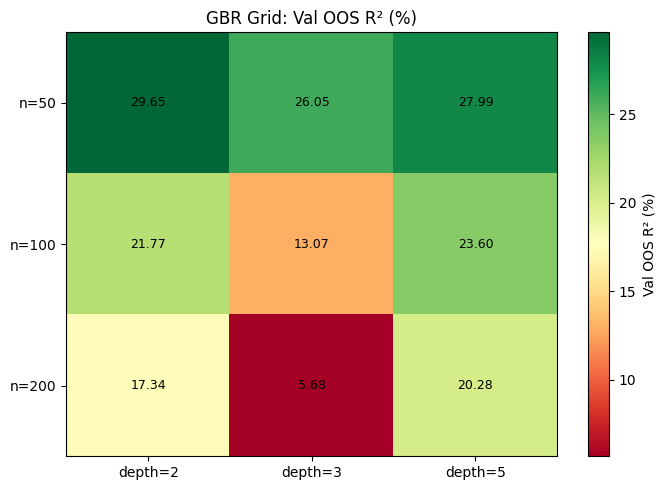

In [6]:
grid_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'model'} for r in grid_results])
pivot   = grid_df.pivot(index='n_estimators', columns='max_depth', values='oos_r2_val') * 100

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f'depth={v}' for v in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f'n={v}' for v in pivot.index])
ax.set_title('GBR Grid: Val OOS R² (%)')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f'{pivot.values[i, j]:.2f}', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax, label='Val OOS R² (%)')
plt.tight_layout()
plt.show()

## Step 4 — Final Evaluation on All Splits

In [7]:
m = best['model']
preds = {'train': m.predict(X_train), 'val': m.predict(X_val), 'test': m.predict(X_test)}
metrics = evaluate_splits(y_train, preds['train'], y_val, preds['val'], y_test, preds['test'], y_train_mean)

print('GBR — BEST MODEL EVALUATION')
print('=' * 55)
print(f"  n_estimators  : {best['n_estimators']}")
print(f"  max_depth     : {best['max_depth']}")
print(f"  learning_rate : {CONFIG['LEARNING_RATE']}")
print(f"  subsample     : {CONFIG['SUBSAMPLE']}")
print()
print(f"  Train R²      : {metrics['r2_train']*100:+.4f}%")
print(f"  Val R²        : {metrics['r2_val']*100:+.4f}%")
print(f"  Test R²       : {metrics['r2_test']*100:+.4f}%")
print()
print(f"  OOS R² Val    : {metrics['oos_r2_val']*100:+.4f}%")
print(f"  OOS R² Test   : {metrics['oos_r2_test']*100:+.4f}%")
print('=' * 55)

GBR — BEST MODEL EVALUATION
  n_estimators  : 50
  max_depth     : 2
  learning_rate : 0.1
  subsample     : 0.8

  Train R²      : +56.7429%
  Val R²        : +28.3885%
  Test R²       : -0.8531%

  OOS R² Val    : +29.6451%
  OOS R² Test   : -0.2907%


## Step 5 — Feature Importance

Importance = total reduction in impurity (MSE) from all splits on each feature across all trees.

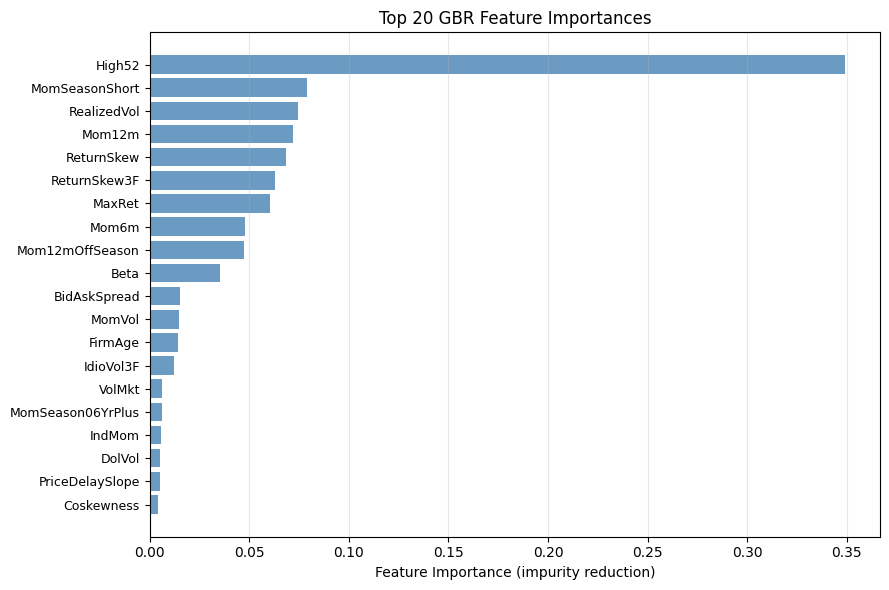

In [8]:
top_n = 20
imp_df = pd.DataFrame({'feature': feature_cols, 'importance': m.feature_importances_})
imp_df = imp_df.sort_values('importance', ascending=False).head(top_n)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(range(top_n), imp_df['importance'].values, color='steelblue', alpha=0.8)
ax.set_yticks(range(top_n))
ax.set_yticklabels(imp_df['feature'].values, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (impurity reduction)')
ax.set_title(f'Top {top_n} GBR Feature Importances')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## Step 6 — Portfolio Formation & Sharpe Ratio

GBR LONG-SHORT PORTFOLIO
  Months        : 552
  Mean monthly  : 9.2345%
  Std monthly   : 8.2289%
  Sharpe (ann.) : 3.8874


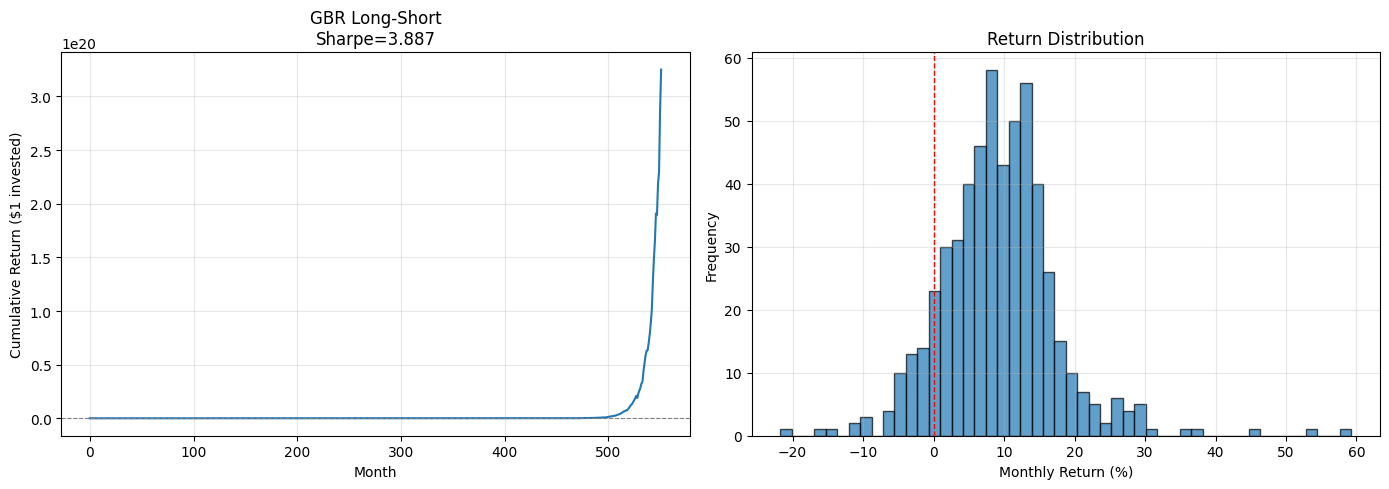

In [9]:
test_df = df.loc[y_test.index, [CONFIG['DATE_COL'], CONFIG['ID_COL'], CONFIG['TARGET_COL']]].copy()
test_df['predicted_ret'] = preds['test']
test_df = test_df.rename(columns={CONFIG['TARGET_COL']: 'actual_ret'})

port_returns, comp_df = form_long_short_portfolio(
    test_df, CONFIG['DATE_COL'], 'predicted_ret', 'actual_ret', CONFIG['N_DECILES']
)
port_stats = portfolio_summary(port_returns)

print('GBR LONG-SHORT PORTFOLIO')
print('=' * 50)
print(f"  Months        : {port_stats['n_periods']}")
print(f"  Mean monthly  : {port_stats['mean_period_return']*100:.4f}%")
print(f"  Std monthly   : {port_stats['std_period_return']*100:.4f}%")
print(f"  Sharpe (ann.) : {port_stats['sharpe_annualized']:.4f}")
print('=' * 50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cumulative = (1 + port_returns).cumprod()
axes[0].plot(range(len(cumulative)), cumulative.values, linewidth=1.5)
axes[0].axhline(y=1, color='gray', linestyle='--', linewidth=0.8)
axes[0].set(xlabel='Month', ylabel='Cumulative Return ($1 invested)',
            title=f'GBR Long-Short\nSharpe={port_stats["sharpe_annualized"]:.3f}')
axes[0].grid(True, alpha=0.3)
axes[1].hist(port_returns.values * 100, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1)
axes[1].set(xlabel='Monthly Return (%)', ylabel='Frequency', title='Return Distribution')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 7 — Save Results

In [10]:
if CONFIG['SAVE_RESULTS']:
    summary = build_run_summary(
        model_name='GBR', description='Gradient Boosting Regression',
        tuning_params=f"n_estimators={best['n_estimators']}, max_depth={best['max_depth']}, lr={CONFIG['LEARNING_RATE']}",
        metrics=metrics, portfolio_stats=port_stats, split_info=split_info,
        n_features=len(feature_cols), fill_value=CONFIG['MISSING_FILL_VALUE'],
        standardized=False, notebook='gbr_regression',
    )
    print(save_run_summary(summary, CONFIG['OUTPUT_DIR'], 'gbr_summary.csv'))
    print(save_portfolio_compositions(comp_df, CONFIG['OUTPUT_DIR'], 'gbr_portfolios.csv'))
else:
    print('SAVE_RESULTS = False — skipping.')

results/gbr_summary.csv
results/gbr_portfolios.csv
